# 05 - Visualizaciones exploratorias

**Responsable principal:** María José Girón

**Actividad de la guia:** 4d (graficos exploratorios) y parte de *Analisis Exploratorio* (30 pts: histogramas, cajas y bigotes, dispersion, graficos de barra).

**Objetivo de este notebook:** generar y guardar en `reports/figures/` los graficos que se van a usar en el informe y la presentacion. Independiente de 01/02/03/04.

In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import data_loading as dl

sns.set_theme(style="whitegrid")


In [8]:
FIGURES_DIR = config.ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [9]:
# Cargar la metadata de las secuencias
train_df = dl.load_train_index()

print("Dimensiones de train_df:", train_df.shape)
display(train_df.head())

Dimensiones de train_df: (67208, 5)


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


## 1. Histograma: longitud de secuencia

*Interpretación*

- Sesgo a la derecha, la moda se concentra entre los 100 y 150 frames por seña.
- La mayor parte de los datos se ubica ene lr ango de 50 a 250 frames.
- Existe una cola hacia la derecha (400-750 framse), indicando que hay señas o participantes con pausas largas o frases muy extensas.

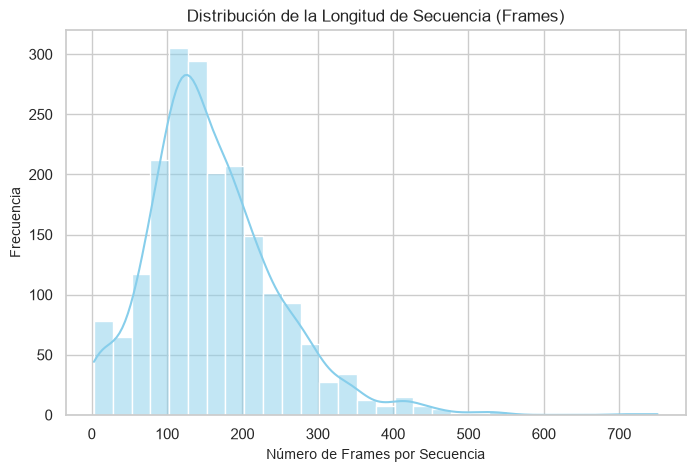

In [11]:
# Cargar la muestra representativa de secuencias para obtener 'seq_len'
sample_rows = []
for rel_path in config.SAMPLE_LANDMARK_PATHS:
    df_sample = dl.load_landmarks(dl.landmark_path(rel_path))
    
    # Si 'frame' está como columna o índice, contamos los frames únicos por secuencia
    if "frame" in df_sample.columns:
        counts = df_sample.groupby("sequence_id")["frame"].nunique()
    else:
        # Si la secuencia está agrupada por el índice
        counts = df_sample.groupby(level=0).size()

    for seq_id, frame_count in counts.items():
        sample_rows.append({"sequence_id": seq_id, "seq_len": frame_count})

sample_seq_df = pd.DataFrame(sample_rows)

# Crear la figura y el histograma
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=sample_seq_df, x="seq_len", bins=30, kde=True, ax=ax, color="skyblue")

ax.set_title("Distribución de la Longitud de Secuencia (Frames)", fontsize=12)
ax.set_xlabel("Número de Frames por Secuencia", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "hist_seq_len.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Histograma: longitud de frase

- Existe un pico inusual, denotando una moda en 12 carácteres.
- Fuera del punto anterior, las frases varían entre 10 y 30 caracteres, decayendo a medida que aumenta la longitud.
- Frases con <8 caracteres son inusuales.
- Mayor parte de frases objetivas tendrán longitud máxima de alrededor de 31 caracteres.

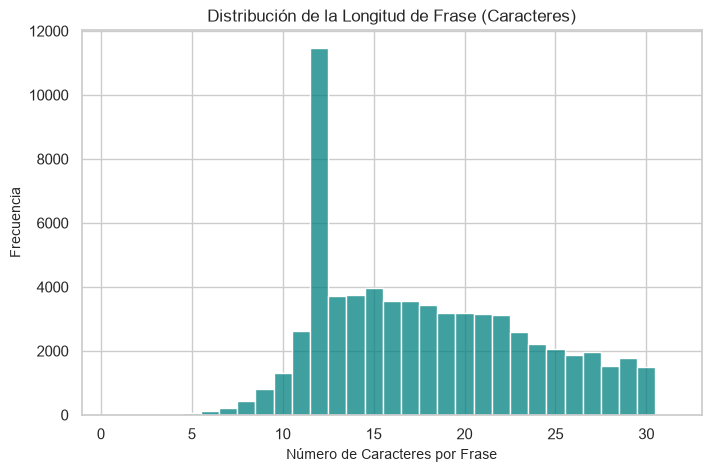

In [12]:
# Calcular la longitud del texto/frase en train_df
train_df["phrase_len"] = train_df["phrase"].str.len()

# Crear la figura y el histograma
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=train_df, x="phrase_len", discrete=True, ax=ax, color="teal")

ax.set_title("Distribución de la Longitud de Frase (Caracteres)", fontsize=12)
ax.set_xlabel("Número de Caracteres por Frase", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)

# Guardar la figura
fig.savefig(FIGURES_DIR / "hist_phrase_len.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Diagrama de caja y bigotes: longitud de secuencia por participante

TODO

In [ ]:
# TODO


## 4. Grafico de dispersion: longitud de secuencia vs. longitud de frase

TODO

In [ ]:
# TODO


## 5. Grafico de barras: frecuencia de caracteres en las frases

TODO

In [ ]:
# TODO


## 6. Visualizacion de una secuencia (trayectoria de landmarks de mano)

TODO: graficar, para una secuencia de ejemplo, la posicion (x, y) de los landmarks de una mano a lo largo de los frames (una linea/scatter por frame o animacion simple). Ayuda a entender visualmente que esta "viendo" el modelo.

In [ ]:
# TODO


## 7. Notas de los graficos

TODO: para cada grafico, una o dos frases explicando que muestra y por que importa (la guia pide explicar los hallazgos, no solo mostrar el grafico).

TODO